How much of the scatter that we observe in the difference between the expected $V(0.4R_{26})$ (from the MaNGA rotation curve fits of Ravi+26) and what we calculate from our DESI observations is due to the known uncertainties in the DESI fiber positioning?

In [166]:
import numpy as np
import numpy.ma as ma

from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import FlatLambdaCDM
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
import astropy.constants as const
import astropy.units as u

import os
# rotcurvepath = os.path.join(os.environ['HOME'], 'desi/RotationCurves/spirals')
rotcurvepath = os.path.join(os.environ['HOME'], 'RotationCurves/spirals')
# rotcurvepath = os.path.join(os.environ['HOME'], 'Documents/Research/Rotation_curves/RotationCurves/spirals')
import sys
sys.path.insert(1, rotcurvepath)
from dark_matter_mass_v1 import rot_fit_BB
from DRP_vel_map_functions import deproject_spaxel

from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
mpl.rc('font', size=12)

In [3]:
h = 1
H0 = 100*h*u.km/u.s/u.Mpc

c = const.c.to('km/s')

q0 = 0.2

MANGA_SPAXEL_SIZE = 0.5*u.arcsec

# Redrock systematic duplicate redshift uncertainty (from Lan+23)
dv_sys = 7 # km/s
dz_sys = dv_sys/c.value
#### ultimately dz = (1+z) dv/c, but we will multiply this by (1+z) for each observation

cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)

# Import data

## Original Iron healpix query results
We need to know the location of each fiber.

In [4]:
tiron = Table.read('/global/cfs/projectdirs/desi/science/td/pv/tfgalaxies/desi_pv_tf_iron_healpix.fits')
# tiron = Table.read('/Users/kdouglass/Documents/Research/data/DESI/Y1/desi_pv_tf_iron_healpix.fits')
tiron[:5]

TARGETID,TARGET_RA,TARGET_DEC,HEALPIX,SURVEY,Z,ZERR,ZWARN,DELTACHI2,FILENAME,PVTYPE,SGA_ID,RA,DEC
int64,float64,float64,int64,bytes4,float64,float64,int64,float64,bytes65,bytes3,int64,float64,float64
2852147603439621,198.369130660983,36.5372037049171,10475,main,0.815976335547845,7.38513168100107e-05,4,0.128754377365112,iron/healpix/main/dark/104/10475/redrock-main-dark-10475.fits,EXT,649377,198.36913066098333,36.537203704917076
2399148812795907,198.371733180003,36.4994335406917,10475,main,1.11088784970434,7.48767797671894e-05,4,7.9473560154438,iron/healpix/main/bright/104/10475/redrock-main-bright-10475.fits,EXT,649377,198.37173318000336,36.499433540691676
2399382443917318,184.845242475328,49.8157304793777,10995,main,1.14739342108157,0.000146302276719084,4,2.56771463155746,iron/healpix/main/bright/109/10995/redrock-main-bright-10995.fits,EXT,1008911,184.84524247532795,49.81573047937771
2399634072797192,184.341289722203,70.8283725474297,11965,main,1.51703376230705,6.28979649962091e-05,4,4.76254060305655,iron/healpix/main/bright/119/11965/redrock-main-bright-11965.fits,EXT,241234,184.34128972220284,70.82837254742968
2852141710442505,123.256011148025,36.2652948002806,6448,main,0.00787379494184006,3.4714052819995e-05,0,22.1719104201402,iron/healpix/main/dark/64/6448/redrock-main-dark-6448.fits,EXT,31591,123.25601114802525,36.26529480028061


### Update all Redrock uncertainties to account for 7 km/s statistical uncertainty

In [5]:
tiron['ZERR_MOD'] = np.sqrt(tiron['ZERR']**2 + (dz_sys*(1 + tiron['Z']))**2)

## Iron VI file

In [6]:
iron_VI = Table.read('../../../TF/Y1/iron_VI.txt', format='ascii.commented_header')

### Remove targets that don't pass VI

In [7]:
VI_pass = np.ones(len(tiron), dtype=bool)

for targetid in iron_VI['TARGETID']:

    if targetid in tiron['TARGETID']:
        VI_pass = VI_pass & (tiron['TARGETID'] != targetid)

tiron_goodVI = tiron[VI_pass]

## SGA

This is the catalog that we used for the TF analysis.

In [8]:
# using tf v15 catalog for update rot vel uncertainties
tf_targets = Table.read('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1/DESI-DR1_TF_pv_cat_v15.fits')
# tf_targets = Table.read('/Users/kdouglass/Documents/Research/data/DESI/Y1/DESI-DR1_TF_pv_cat_v15.fits')
tf_targets[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,V_0p4R26,V_0p4R26_ERR,PHOTSYS,MORPHTYPE_AI,JOHN_VI,Z_DESI_CMB,G_MAG_SB26_CORR,R_MAG_SB26_CORR,Z_MAG_SB26_CORR,G_MAG_SB26_ERR_CORR,R_MAG_SB26_ERR_CORR,Z_MAG_SB26_ERR_CORR,MU_ZCMB,R_ABSMAG_SB26,MU_ZCMB_ERR,R_ABSMAG_SB26_ERR,DWARF,GOOD_MORPH,GOOD_VEL,R_ABSMAG_SB26_TF,R_ABSMAG_SB26_TF_ERR,R_ABSMAG_SB26_TF_ERR_STAT,R_ABSMAG_SB26_TF_ERR_SYS,MU_TF,MU_TF_ERR,LOGDIST,LOGDIST_ERR,MAIN
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,mag,,mag,,,,,,,,,,,mag,mag,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,float64,float64,bytes1,bytes10,bytes6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,bool,bool,float64,float64,float64,float64,float64,float64,float64,float64,bool
38.0,SGA-2020 38,SDSSJ140638.88+393138.1,3558705,211.66194,39.5272341,S?,81.63,0.35318315,0.37757218,0.08108376,24.72948,18.361,False,LEDA-20181114,12,SDSSJ140638.88+393138.1,1,True,211.66194,39.5272341,0.35318315,2115p395,211.66203166014844,39.52724032794356,0.41757938,SB26,82.21093,0.41431504,211.6619547015994,39.52729608884245,8.520181,5.252184,4.0750155,3.3951538,3.3006833,4.4037066,5.5453897,6.693271,7.8023033,8.999919,10.213078,11.41192,12.527382,19.246052,18.406073,17.931826,18.841032,18.092857,17.659027,18.566164,17.886087,17.47688,18.383362,17.749825,17.355968,18.261652,17.655558,17.284552,18.168955,17.588947,17.231817,18.101948,17.547142,17.20673,18.055267,17.516266,17.18719,18.023865,1

In [9]:
SGA_dict = {}

for i in range(len(tf_targets)):
    
    SGA_dict[int(tf_targets['SGA_ID'][i])] = i

## SDSS MaNGA best fits

Nitya's fitting from 2025 on DR17 (Ravi+26)

In [10]:
MaNGA_fits = Table.read('../Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits', # Ravi et al. (2026)
                        format='fits')
MaNGA_fits[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

## SDSS MaNGA cross-match file

In [11]:
SGA_MaNGA = Table.read('../../MaNGA_SGA_crossmatch_2022-06-28.txt', 
                       format='ascii.commented_header')

SGA_MaNGA[:5]

plate,ifudsgn,plateifu,SGA_ID
int64,int64,str11,int64
8716,3703,8716-3703,927743
9086,6104,9086-6104,1003700
11967,1902,11967-1902,196166
8613,6104,8613-6104,376271
10001,3703,10001-3703,937846


### Add TF catalog info to SGA-MaNGA table

In [31]:
SGA_MaNGA['RA'] = np.nan
SGA_MaNGA['DEC'] = np.nan
SGA_MaNGA['Z_DESI'] = np.nan
SGA_MaNGA['ZERR_DESI'] = np.nan
SGA_MaNGA['R26'] = np.nan
SGA_MaNGA['BA'] = np.nan
SGA_MaNGA['PA'] = np.nan
SGA_MaNGA['V_0p4R26'] = np.nan
SGA_MaNGA['V_0p4R26_ERR'] = np.nan

for i in range(len(SGA_MaNGA)):
    
    # Find the row in SGA for this galaxy
    try:
        SGA_idx = SGA_dict[SGA_MaNGA['SGA_ID'][i]]

        # Set the center coordinates of this galaxy
        SGA_MaNGA['RA'][i] = tf_targets['RA'][SGA_idx]
        SGA_MaNGA['DEC'][i] = tf_targets['DEC'][SGA_idx]
        
        # Set the redshift of this galaxy
        SGA_MaNGA['Z_DESI'][i] = tf_targets['Z_DESI'][SGA_idx]
        SGA_MaNGA['ZERR_DESI'][i] = tf_targets['ZERR_DESI'][SGA_idx]
        
        # # Transfer R26 over to the SGA_MaNGA table
        SGA_MaNGA['R26'][i] = 0.5*tf_targets['D26'][SGA_idx]
        
        # # Transfer b/a over to the SGA_MaNGA table
        SGA_MaNGA['BA'][i] = tf_targets['BA'][SGA_idx]
        
        # # Transfer phi over to the SGA_MaNGA table
        SGA_MaNGA['PA'][i] = tf_targets['PA'][SGA_idx]

        # Transfer over velocity and err at 0.4 R26
        SGA_MaNGA['V_0p4R26'][i] = tf_targets['V_0p4R26'][SGA_idx]
        SGA_MaNGA['V_0p4R26_ERR'][i] = tf_targets['V_0p4R26_ERR'][SGA_idx]

    except:
        continue

In [32]:
print(len(SGA_MaNGA), len(np.unique(SGA_MaNGA['SGA_ID'])))

8422 8285


# Filter the table to remove objects without a rotational velocity

In [33]:
hasV = np.isfinite(SGA_MaNGA['V_0p4R26'])

SGA_MaNGA_dr1 = SGA_MaNGA[hasV]

print(len(SGA_MaNGA_dr1), len(np.unique(SGA_MaNGA_dr1['SGA_ID'])))

276 270


# Add the distances to the SDSS MaNGA - SGA cross-match table

In [34]:
# add sky fiber dist in radians
SGA_MaNGA_dr1['SKY_FIBER_DIST'] = (0.4*SGA_MaNGA_dr1['R26']*u.arcmin).to('radian')

In [35]:
SGA_MaNGA_dr1

plate,ifudsgn,plateifu,SGA_ID,Z_DESI,ZERR_DESI,R26,BA,PA,V_0p4R26,V_0p4R26_ERR,RA,DEC,SKY_FIBER_DIST
,,,,,,,,,,,,,rad
int64,int64,str11,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
9045,3702,9045-3702,29152,0.033320236763565,2.4460755524616512e-05,0.31793898344039917,0.6588062047958374,168.80343627929688,136.6548735566878,11.307697452589558,225.78123715633816,31.203921388066558,3.699388054319129e-05
8615,1901,8615-1901,1265162,0.0197616666129208,2.3739602831420816e-05,0.2447134554386139,0.9234866499900818,75.16405487060547,142.94634563209866,29.398587860869817,321.0722024175077,1.0283562713442325,2.8473703475574915e-05
7958,3702,7958-3702,1279893,0.0370122558474312,2.8359203178928903e-05,0.4380972981452942,0.6277525424957275,142.59364318847656,219.66869909615497,14.866859018660882,256.9926010676615,34.81853969792051,5.0974935311510876e-05
11834,6104,11834-6104,1002687,0.0440140222262614,2.6769927473691524e-05,0.2553322911262512,0.4506562352180481,161.87460327148438,152.22107611896863,6.274213931761072,224.49227347082032,1.4735975631988745,2.9709261112091895e-05
12081,12702,12081-12702,929612,0.0418290423138136,2.8687714937533415e-05,0.3322809934616089,0.48097705841064453,146.14280700683594,160.37643562955543,13.913301987459494,31.585416742353456,0.6171533049632267,3.8662649184685504e-05
11824,12701,11824-12701,211567,0.0570328748289802,2.511462765932501e-05,0.3941173851490021,0.7089425325393677,104.9497299194336,182.94968573201237,7.58203027388956,222.96745738032135,5.245660092584866,4.585764006800459e-05
11757,12701,11757-12701,1095337,0.0389700499520749,2.5770288816011948e-05,0.22686167061328888,0.8023555874824524,45.64091110229492,94.92560511993292,18.073962379466323,248.82363417478194,26.30468108562836,2.6396553991845033e-05
9031,12702,9031-12702,1205063,0.0403160857304091,3.0113708761576984e-05,0.2188577502965927,0.9376584887504578,28.06189727783203,24.421184083062574,13.3396523637537,240.10345512972236,43.93434867773967,2.546525557455426e-05


# Temporarily set bad MaNGA galaxies to have -999 values

These were determined from VI of the MaNGA fits and maps:
* Galaxies with no data
    * failed T-type cut: 9862-12704 (T-type=-0.46)
    * failed smoothness cut:  8951-3704, 11835-6103, 11024-6102
      
* Too much data masked: 8999-6103, 9032-12703
* Merger: 11865-6102
* Bad fits: 8144-3703, 8335-12704, 8977-12704, 9498-12703, 10224-9101, 10497-6103, 11828-12705, 11865-1902, 11949-12702, 11978-12701, 12506-12701, 12512-3701, 12769-12705 
* Successfully refit: 12079-9101 (note mngtarg1 = 0, mngtarg3 > 0), 11955-3703 (note mngtarg1 = 0, mngtarg3 > 0),  '11835-12703', '11982-3702'

In [36]:
bad_gals = ['8999-6103', '9032-12703', '11865-6102', '8144-3703', 
            '8335-12704', '8977-12704', '9498-12703', '10224-9101', 
            '10497-6103', '11828-12705', '11865-1902', '11949-12702', 
            '11978-12701', '12506-12701', '12512-3701', '12769-12705']

for gal_ID in bad_gals:
    idx = np.where(MaNGA_fits['plateifu'] == gal_ID)[0]

    MaNGA_fits['v_max'][idx] = -999

# Add the MaNGA best-fit values to the table

In [37]:
SGA_MaNGA_dr1['Vmax_map'] = np.nan
SGA_MaNGA_dr1['Vmax_err_map'] = np.nan
SGA_MaNGA_dr1['Rturn_map'] = np.nan
SGA_MaNGA_dr1['alpha_map'] = np.nan

SGA_MaNGA_dr1['ba_map'] = np.nan
SGA_MaNGA_dr1['ba_err_map'] = np.nan
SGA_MaNGA_dr1['ba_NSA'] = np.nan

SGA_MaNGA_dr1['phi_map'] = np.nan
SGA_MaNGA_dr1['phi_err_map'] = np.nan
SGA_MaNGA_dr1['phi_NSA'] = np.nan

SGA_MaNGA_dr1['x0_map'] = np.nan
SGA_MaNGA_dr1['x0_err_map'] = np.nan
SGA_MaNGA_dr1['y0_map'] = np.nan
SGA_MaNGA_dr1['y0_err_map'] = np.nan

SGA_MaNGA_dr1['chi2_map'] = np.nan

SGA_MaNGA_dr1['Z_NSA'] = np.nan

for i in range(len(SGA_MaNGA_dr1)):
    
    gal_id = SGA_MaNGA_dr1['plateifu'][i]
    
    # Find galaxy row in MaNGA fits table
    i_fit = MaNGA_fits['plateifu'] == SGA_MaNGA_dr1['plateifu'][i]
    
    # Copy best-fit parameter values from fit table to galaxy table
    if (np.sum(i_fit) > 0):
        
        SGA_MaNGA_dr1['Vmax_map'][i] = MaNGA_fits['v_max'][i_fit]
        SGA_MaNGA_dr1['Vmax_err_map'][i] = MaNGA_fits['v_max_err'][i_fit]
        SGA_MaNGA_dr1['Rturn_map'][i] = MaNGA_fits['r_turn'][i_fit]
        SGA_MaNGA_dr1['alpha_map'][i] = MaNGA_fits['alpha'][i_fit]
        
        SGA_MaNGA_dr1['ba_map'][i] = MaNGA_fits['ba'][i_fit]
        SGA_MaNGA_dr1['ba_err_map'][i] = MaNGA_fits['ba_err'][i_fit]
        SGA_MaNGA_dr1['ba_NSA'][i] = MaNGA_fits['nsa_elpetro_ba'][i_fit]
        
        SGA_MaNGA_dr1['phi_map'][i] = MaNGA_fits['phi'][i_fit]
        SGA_MaNGA_dr1['phi_err_map'][i] = MaNGA_fits['phi_err'][i_fit]
        SGA_MaNGA_dr1['phi_NSA'][i] = MaNGA_fits['nsa_elpetro_phi'][i_fit]

        SGA_MaNGA_dr1['x0_map'][i] = MaNGA_fits['x0'][i_fit]
        SGA_MaNGA_dr1['x0_err_map'][i] = MaNGA_fits['x0_err'][i_fit]
        SGA_MaNGA_dr1['y0_map'][i] = MaNGA_fits['y0'][i_fit]
        SGA_MaNGA_dr1['y0_err_map'][i] = MaNGA_fits['y0_err'][i_fit]

        SGA_MaNGA_dr1['chi2_map'][i] = MaNGA_fits['chi2'][i_fit]
        
        SGA_MaNGA_dr1['Z_NSA'][i] = MaNGA_fits['nsa_z'][i_fit]
        

# Flip all -99 values to NaN
for col_name in SGA_MaNGA_dr1.colnames:
    
    bad_values = SGA_MaNGA_dr1[col_name] == -999
    
    if np.any(bad_values):
        SGA_MaNGA_dr1[col_name][bad_values] = np.nan

/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/astropy/table/column.py:1372: UserWarning: Warning: converting a masked element to nan.
  self.data[index] = value


In [38]:
good_V = np.isfinite(SGA_MaNGA_dr1['Vmax_map']) & np.isfinite(SGA_MaNGA_dr1['V_0p4R26'])

print(np.sum(good_V))

257


In [39]:
# Also remove those galaxies from the final sample that have V(R26) < 0.9Vmax, and have Vmax > 1000 km/s

# 1 - Convert R26 to kpc for each galaxy
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)
dist_to_galaxy = Distance(z=SGA_MaNGA_dr1['Z_DESI'], cosmology=Planck18_h)
R26_kpc = dist_to_galaxy.to('kpc')*np.tan((SGA_MaNGA_dr1['R26']*u.arcmin).to(u.rad))

# 2 - Compute V(R26)
SGA_MaNGA_dr1['Vfit_R26'] = rot_fit_BB(R26_kpc.data, 
                                       [SGA_MaNGA_dr1['Vmax_map'], 
                                        SGA_MaNGA_dr1['Rturn_map'], 
                                        SGA_MaNGA_dr1['alpha_map']])

# 3 - Filter out those with V(R26) < 0.9Vmax
goodVmax = SGA_MaNGA_dr1['Vfit_R26'] >= 0.9*SGA_MaNGA_dr1['Vmax_map']

# 4 - Filter out those with Vmax > 1000 km/s
lowVmax = SGA_MaNGA_dr1['Vmax_map'] < 1000.

final_sample = good_V & goodVmax & lowVmax

In [40]:
SGA_MaNGA_dr1_final = SGA_MaNGA_dr1[final_sample]
SGA_MaNGA_dr1_final

plate,ifudsgn,plateifu,SGA_ID,Z_DESI,ZERR_DESI,R26,BA,PA,V_0p4R26,V_0p4R26_ERR,RA,DEC,SKY_FIBER_DIST,Vmax_map,Vmax_err_map,Rturn_map,alpha_map,ba_map,ba_err_map,ba_NSA,phi_map,phi_err_map,phi_NSA,x0_map,x0_err_map,y0_map,y0_err_map,chi2_map,Z_NSA,Vfit_R26
,,,,,,,,,,,,,rad,,,,,,,,,,,,,,,,,
int64,int64,str11,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
9045,3702,9045-3702,29152,0.033320236763565,2.4460755524616512e-05,0.31793898344039917,0.6588062047958374,168.80343627929688,136.6548735566878,11.307697452589558,225.78123715633816,31.203921388066558,3.699388054319129e-05,210.50452801297985,1.8353976854896468,0.7066919287420622,0.9111401871299377,0.8234098343647784,0.001601497928492459,0.70429,170.71749392618315,0.02929622324244995,168.862,21.882076864143773,0.005466208942145591,22.188064369156837,0.007755939838456064,46.16357347070347,0.0333513,190.7436504644614
8615,1901,8615-1901,1265162,0.0197616666129208,2.3739602831420816e-05,0.2447134554386139,0.9234866499900818,75.16405487060547,142.94634563209866,29.398587860869817,321.0722024175077,1.0283562713442325,2.8473703475574915e-05,220.16802918955494,0.938473172075278,0.9732954258408208,2.5112860326014714,0.9557675585663513,0.00040024946764247393,0.864664,116.18630266418596,0.03337353804379676,29.9028,15.766596851398912,0.01848932560602464,14.491757466046138,0.022291160399820775,254.08051342996677,0.0197432,218.07771302058381
7958,3702,7958-3702,1279893,0.0370122558474312,2.8359203178928903e-05,0.4380972981452942,0.6277525424957275,142.59364318847656,219.66869909615497,14.866859018660882,256.9926010676615,34.81853969792051,5.0974935311510876e-05,242.9211676900525,0.1875765246066455,1.365763143678639,3.082085057706107,0.678949712986619,0.0005240797629047349,0.719594,321.0557249418591,0.015508704418586036,138.715,22.231848341492075,0.004116164357321055,22.113666689527047,0.004096986301522966,32.086971113181455,0.0370471,242.86733688210546
11834,6104,11834-6104,1002687,0.0440140222262614,2.6769927473691524e-05,0.2553322911262512,0.4506562352180481,161.87460327148438,152.22107611896863,6.274213931761072,224.49227347082032,1.4735975631988745,2.9709261112091895e-05,232.29567853040538,3.5372042573275575,1.6157067061530481,2.2182435957133957,0.7980107504115111,0.005971267624381377,0.7131611,162.8144980146715,0.1086854487008954,160.61732,24.486365545597476,0.015233610676827455,36.484026774689966,0.02462972571986479,4.049425591865072,0.044045065,230.53071367484205
12081,12702,12081-12702,929612,0.0418290423138136,2.8687714937533415e-05,0.3322809934616089,0.48097705841064453,146.14280700683594,160.37643562955543,13.913301987459494,31.585416742353456,0.6171533049632267,3.8662649184685504e-05,195.42432287880288,1.3346281500087767,1.3198023994720334,1.1216729306540982,0.6541854019632092,0.003249980121659414,0.5533,324.31771976680415,0.10032848698407756,145.41603,36.257802459299405,0.024843183463947694,36.251797542590616,0.026449329132018303,2.95303632544946,0.041768476,182.42008819109282
11824,12701,11824-12701,211567,0.0570328748289802,2.511462765932501e-05,0.3941173851490021,0.7089425325393677,104.9497299194336,182.94968573201237,7.58203027388956,222.96745738032135,5.245660092584866,4.585764006800459e-05,213.21030009683315,0.37995901749603017,3.2421984975912386,4.107502810453571,0.7709798023865316,0.000980767615119872,0.79347116,277.7050698514268,0.022168037157852916,112.61641,37.21675625452923,0.00973518309397235,36.962858957869834,0.005981815196063073,13.838433863696032,0.05706307,213.18333753615693
11757,12701,11757-12701,1095337,0.0389700499520749,2.5770288816011948e-05,0.22686167061328888,0.8023555874824524,45.64091110229492,94.92560511993292,18.073962379466323,248.82363417478194,26.30468108562836,2.6396553991845033e-05,139.8589447091876,3.48141965647591,1.9702654263831174,3.565549293643847,0.9012611974513942,0.0

## Find repeat galaxies in the MaNGA observations and keep the best $\chi^2$ fit

In [41]:
unique_manga, unique_manga_counts = np.unique(SGA_MaNGA_dr1_final['SGA_ID'], return_counts=True)

repeat_manga_sga_ids = unique_manga[unique_manga_counts > 1]

bad_repeats = np.ones(len(SGA_MaNGA_dr1_final), dtype=bool)

for sga_id in repeat_manga_sga_ids:

    # Find all observations with this SGA ID
    obs = SGA_MaNGA_dr1_final['SGA_ID'] == sga_id
    plateifus = SGA_MaNGA_dr1_final['plateifu'][obs]

    # Identify which of these has the minimum chi2
    good_idx = np.argmin(SGA_MaNGA_dr1_final['chi2_map'][obs])

    # Create boolean to identify all those which need to be removed
    cut = np.ones(len(plateifus), dtype=bool)
    cut[good_idx] = 0
    
    # Set all other fits of this galaxy to 0 (to be removed)
    for plateifu in plateifus[cut]:
        bad_repeats[SGA_MaNGA_dr1_final['plateifu'] == plateifu] = 0

final_MaNGA_sample = SGA_MaNGA_dr1_final[bad_repeats]

## Compute $V(0.4R_{26})$ based on the best fits

In [97]:
dist_to_galaxy = cosmo.comoving_distance(final_MaNGA_sample['Z_DESI'])

p4R26_kpc = dist_to_galaxy.to('kpc')*np.tan(final_MaNGA_sample['SKY_FIBER_DIST'])

final_MaNGA_sample['Vfit_0p4R26'] = rot_fit_BB(p4R26_kpc.data, 
                                               [final_MaNGA_sample['Vmax_map'], 
                                                final_MaNGA_sample['Rturn_map'], 
                                                final_MaNGA_sample['alpha_map']])

In [102]:
delta_pa = np.abs((final_MaNGA_sample['phi_map']%180.) - final_MaNGA_sample['PA'])
delta_pa[delta_pa > 90.] = 180. - delta_pa[delta_pa > 90.]
final_MaNGA_sample['delta_phi'] = delta_pa

cosi2_sga = (final_MaNGA_sample['BA']**2 - q0**2)/(1 - q0**2)
cosi2_manga = (final_MaNGA_sample['ba_map']**2 - q0**2)/(1 - q0**2)

cosi2_sga[cosi2_sga < 0] = 0.
cosi2_manga[cosi2_manga < 0] = 0.

DESI_corrected = (1./np.cos(delta_pa*np.pi/180.))*(np.sin(np.arccos(np.sqrt(cosi2_sga)))/np.sin(np.arccos(np.sqrt(cosi2_manga))))*final_MaNGA_sample['V_0p4R26']

final_MaNGA_sample['Vfit_corr_0p4R26'] = np.cos(delta_pa*np.pi/180.)*(np.sin(np.arccos(np.sqrt(cosi2_manga)))/np.sin(np.arccos(np.sqrt(cosi2_sga))))*final_MaNGA_sample['Vfit_0p4R26']

In [146]:
final_MaNGA_sample['Vfit_corr_0p4R26_err'] = np.nan

# Convert b/a to i (to match what is in the Hessians)
final_MaNGA_sample['i_map'] = np.arccos(np.sqrt((final_MaNGA_sample['ba_map']**2 - q0**2)/(1 - q0**2)))

for i in range(len(final_MaNGA_sample)):
    
    if np.isfinite(final_MaNGA_sample['Vmax_map'][i]) and np.isfinite(final_MaNGA_sample['V_0p4R26'][i]):
        
        gal_ID = str(final_MaNGA_sample['plate'][i]) + '-' + str(final_MaNGA_sample['ifudsgn'][i])

        try:
            Hessian = np.load('/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/' + gal_ID + '_Hessian.npy')
            # Hessian = np.load('/pscratch/sd/n/nravi/dr17_Hessians/' + gal_ID + '_Hessian.npy')

            hess_inv_all = 2*np.linalg.inv(Hessian)
            
            # Reconstruct the inverse Hessian to contain just the parameters that we need
            hess_inv = np.zeros((5,5))
            hess_inv[-4:,-4:] = hess_inv_all[-4:,-4:] # copies phi, Vmax, Rturn, and alpha
            hess_inv[0,0] = hess_inv_all[1,1] # copies i
            hess_inv[0,-4:] = hess_inv_all[1,-4:] # copies off-diagonal elements for i
            hess_inv[-4:,0] = hess_inv_all[-4:,1] # copies off-diagonal elements for i

            N_samples = 10000

            random_sample = np.random.multivariate_normal(mean=[final_MaNGA_sample['i_map'][i],
                                                                final_MaNGA_sample['phi_map'][i], 
                                                                final_MaNGA_sample['Vmax_map'][i], 
                                                                final_MaNGA_sample['Rturn_map'][i], 
                                                                final_MaNGA_sample['alpha_map'][i]], 
                                                          cov=hess_inv, 
                                                          size=N_samples)

            # Remove bad samples (those with negative values for any of the parameters)
            is_good_random = np.all(random_sample > 0, axis=1)
            good_randoms = random_sample[is_good_random, :]

            # Calculate values of curve at this location
            y_sample = rot_fit_BB(R26_kpc[i].value, [good_randoms[:,-3], 
                                                     good_randoms[:,-2], 
                                                     good_randoms[:,-1]])
            
            # Adjust for differences in i and phi
            delta_pa_sample = np.abs((good_randoms[:,1]%180.) - final_MaNGA_sample['PA'][i])
            delta_pa_sample[delta_pa_sample > 90.] = 180. - delta_pa_sample[delta_pa_sample > 90.]
            
            y_sample = np.cos(delta_pa_sample*np.pi/180)*(np.sin(good_randoms[:,0])/np.sin(np.arccos(np.sqrt(cosi2_sga[i]))))*y_sample

            final_MaNGA_sample['Vfit_corr_0p4R26_err'][i] = np.std(y_sample, axis=0)
            
        except (FileNotFoundError, np.linalg.LinAlgError) as error:
            print(gal_ID, error)

/tmp/ipykernel_2272339/3336611399.py:27: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[final_MaNGA_sample['i_map'][i],


12079-9101 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/12079-9101_Hessian.npy'
11955-3703 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/11955-3703_Hessian.npy'


# Model DESI observations

For each galaxy that is in our Iron sample AND has a MaNGA velocity map model, 
1. Identify which observations are of this galaxy (both center and $0.4R_{26}$
2. Filter DESI observations to keep only those that went into the calculation of $V(0.4R_{26})$ (both centers and those at $0.4R_{26}$)
3. For each good DESI observation, compute the expected velocity from the MaNGA velocity map model
4. Combine the predicted velocities in a similar manner to how we compute $V(0.4R_{26})$ from the DESI observations

We will do all these steps on a galaxy-by-galaxy basis.  (I think it will be easier to keep track of everything.)

In [91]:
def identify_DESI_obs(DESI_obs, sga_id):
    '''
    For the given sga_id, find all DESI observations taken of this galaxy.
    '''
    gal_idx = DESI_obs['SGA_ID'] == sga_id

    return DESI_obs[gal_idx]

In [43]:
def check_sides(galaxies):
    '''
    Check that the rotational velocities have the same sign on each side of the 
    galaxy.
    '''
    # Find which observations are on the same, opposite side
    same_side = (galaxies['TARGET_RA'] == galaxies['TARGET_RA'][0]) & (galaxies['TARGET_DEC'] == galaxies['TARGET_DEC'][0])

    # Check that all velocities on the same side as the first in the table have 
    # the same sign
    same1 = galaxies['V_ROT'][same_side] > 0
    check_same = np.all(same1 == same1[0])

    # Check if there are observations on the opposite side of the galaxy from 
    # the first one in the table
    if np.sum(same_side) < len(galaxies):

        # Check that all the velocities on this size have the same sign
        same2 = galaxies['V_ROT'][~same_side] > 0
        check_same2 = np.all(same2 == same2[0])

        # Check that the signs are opposite each other on the two sides
        check_opposite = check_same & check_same2 & (same1[0] != same2[0])

        # Combine all the checks into one boolean value
        check_same = check_same & check_same2 & check_opposite

    return check_same

In [89]:
rng = np.random.default_rng()

# Function to filter the DESI observations to keep only those that went into the 
# calculation of V(0.4R26)
def clean_DESI_obs(DESI_obs, gal_coords, R26, ba):
    '''
    Return two sets of observations - centers and those at 0.4R26 - that survive 
    all quality cuts.

    Note that gal_coords should be a SkyCoord object, and R26 needs units.
    '''

    ############################################################################
    # 1. Calculate the on-sky separation between each observation and the 
    #    galaxy's center
    #---------------------------------------------------------------------------
    target_coords = SkyCoord(ra=DESI_obs['RA'], 
                             dec=DESI_obs['DEC'], 
                             unit=u.degree)
    
    DESI_obs['SKY_FIBER_DIST'] = target_coords.separation(gal_coords)
    
    DESI_obs['SKY_FIBER_DIST_R26'] = DESI_obs['SKY_FIBER_DIST'].to('arcmin')/R26
    ############################################################################


    ############################################################################
    # 2. Separate into center and off-center observations
    #---------------------------------------------------------------------------
    # Centers
    centers_boolean = DESI_obs['SKY_FIBER_DIST_R26'] < 0.1
    DESI_centers = DESI_obs[centers_boolean]

    # 0.4R26
    axis_boolean = (DESI_obs['SKY_FIBER_DIST_R26'] > 0.38) & (DESI_obs['SKY_FIBER_DIST_R26'] < 0.42)
    DESI_axis = DESI_obs[axis_boolean]
    ############################################################################


    ############################################################################
    # 3. Clean the center observations
    #---------------------------------------------------------------------------
    good_centers = DESI_centers[(DESI_centers['DELTACHI2'] > 25) & (DESI_centers['ZWARN'] == 0)]
    ############################################################################


    ############################################################################
    # 4. Calculate the rotational velocities of the off-center observations
    #---------------------------------------------------------------------------
    # Calculate the average center redshift
    z_center = np.average(good_centers['Z'], 
                          weights=good_centers['ZERR_MOD']**-2)

    # Calculate the uncertainty in the center redshift
    z_random = np.zeros((len(good_centers), 10000))

    for i in range(len(good_centers)):
        z_random[i] = rng.normal(loc=good_centers['Z'][i], 
                                 scale=good_centers['ZERR_MOD'][i], 
                                 size=10000)

    z_center_random = np.average(z_random, 
                                 weights=np.ones(10000)*(good_centers['ZERR_MOD'][:,None]**-2), 
                                 axis=0)
    z_err_center = np.std(z_center_random)

    # Calculate rotational velocity for each observation
    z_rot = (1 + DESI_axis['Z'])/(1 + z_center) - 1
    DESI_axis['V_ROT'] = c*z_rot

    # Calculate uncertainty in rotational velocity for each observation
    z_axis_random = np.zeros((len(DESI_axis), 10000))

    for i in range(len(DESI_axis)):
        z_axis_random[i] = rng.normal(loc=DESI_axis['Z'][i], 
                                      scale=DESI_axis['ZERR_MOD'][i], 
                                      size=10000)

    z_rot_random = (1 + z_axis_random)/(1 + z_center_random) - 1

    DESI_axis['V_ROT_ERR'] = np.std(np.abs(c*z_rot_random), axis=1)
    # try:
    #     DESI_axis['V_ROT_ERR'] = np.std(np.abs(c*z_rot_random), axis=1)
    # except ValueError:
    #     print(len(good_centers), len(DESI_axis), z_rot_random.shape, z_axis_random.shape, z_center_random.shape)
    ############################################################################


    ############################################################################
    # 5. Correct rotational velocities for inclination angle
    #---------------------------------------------------------------------------
    cosi2 = (ba**2 - q0**2)/(1 - q0**2)

    if cosi2 < 0:
        cosi2 = 0

    DESI_axis['V_ROT'] /= np.sin(np.arccos(np.sqrt(cosi2)))
    DESI_axis['V_ROT_ERR'] /= np.sin(np.arccos(np.sqrt(cosi2)))
    ############################################################################


    ############################################################################
    # 6. Keep only those with 10 < Vrot < 1000 km/s
    #---------------------------------------------------------------------------
    Vgood = (np.abs(DESI_axis['V_ROT']) < 1000) & (np.abs(DESI_axis['V_ROT']) > 10)

    good_axis = DESI_axis[Vgood]
    ############################################################################


    ############################################################################
    # 7. Keep only those with dV/Vmin <= 5
    #---------------------------------------------------------------------------
    good_deltaV = np.ones(len(good_axis), dtype=bool)
    
    if len(good_axis) > 1:
    
        deltachi2_idx = good_axis['DELTACHI2'] >= 25

        Vmin = np.min(np.abs(good_axis['V_ROT']))

        v_norm_min = np.abs(good_axis['V_ROT'])/Vmin

        diff_matrix = np.abs(good_axis['V_ROT']).reshape(len(good_axis), 1) - np.abs(good_axis['V_ROT']).reshape(1, len(good_axis))

        diff_matrix_norm = diff_matrix/Vmin

        if np.any(np.abs(diff_matrix_norm) > 5):

            # Remove all observations with DELTACHI2 < 25
            # Note: This also typically removes observations with ZWARN != 0
            good_deltaV[~deltachi2_idx] = False

            # Check to make sure that, if there are still multiple observations, 
            # they all satisfy our relative velocity criteria
            if np.sum(deltachi2_idx) > 1:

                Vmin = np.min(np.abs(good_axis['V_ROT'][deltachi2_idx]))

                diff_matrix = np.abs(good_axis['V_ROT'][deltachi2_idx]).reshape(np.sum(deltachi2_idx), 1) - np.abs(good_axis['V_ROT']).reshape(1, np.sum(deltachi2_idx))

                diff_matrix_norm = diff_matrix/Vmin

                if np.any(np.abs(diff_matrix_norm) > 5):

                    # Set all these so that we do not look at this galaxy
                    # Note there shouldn't be any that make it in here, because 
                    # all the objects in this file are ones with good final 
                    # velocities
                    good_deltaV[deltachi2_idx] = False

    good_deltaV_axis = good_axis[good_deltaV]
    ############################################################################


    ############################################################################
    # 8. Keep only those with the same velocity sign on the same side (and 
    #    opposite sign on the opposite side)
    #---------------------------------------------------------------------------
    same_side_good = np.ones(len(good_deltaV_axis), dtype=bool)

    if len(good_deltaV_axis) > 1:

        deltachi2_idx = good_deltaV_axis['DELTACHI2'] >= 25

        check_same = check_sides(good_deltaV_axis)

        if ~check_same:
            # At least one of the observations is the wrong sign

            # First, remove all with DELTACHI2 < 25
            same_side_good[~deltachi2_idx] = False

            if np.sum(good_obs_idx) > 1:

                # Recheck those that are left
                check_same_again = check_sides(good_deltaV_axis[deltachi2_idx])

                # If this still fails, remove all observations
                # Note that this should never happen here, because all these 
                # galaxies have good final velocities
                if ~check_same_again:
                    same_side_good[deltachi2_idx] = False

    good_deltaV_axis_same = good_deltaV_axis[same_side_good]
    ############################################################################
    
    return good_centers, good_deltaV_axis_same

In [182]:
MANGA_FOLDER = '/global/cfs/cdirs/sdss/data/sdss/dr17/manga/spectro/'
VEL_MAP_FOLDER = MANGA_FOLDER + 'analysis/v3_1_1/3.1.0/HYB10-MILESHC-MASTARSSP/'

N_samples = 10000

def MaNGA_vel(DESI_obs, MaNGA_fit):
    '''
    Calculate the predicted rotational velocity from the best-fit MaNGA velocity 
    map model.
    '''

    ############################################################################
    # 1. Calculate the deprojected radius between the target and the center of 
    # the velocity map, and the position angle os the observation
    #---------------------------------------------------------------------------
    # Build file name of MaNGA data cube
    gal_plate = MaNGA_fit['plate']
    gal_IFU = MaNGA_fit['ifudsgn']
    
    file_name = str(gal_plate) + '/' + str(gal_IFU) + '/manga-' + str(gal_plate) + '-' + str(gal_IFU) + '-MAPS-HYB10-MILESHC-MASTARSSP.fits.gz'

    # Retrieve the WCS of the MaNGA data cube
    hdul = fits.open(VEL_MAP_FOLDER + file_name)
    wcs_map = WCS(hdul['EMLINE_GVEL'].header)
    hdul.close()
    
    # Convert the (ra,dec) positions of the DESI observations to pixel 
    # coordinates
    DESI_coords = SkyCoord(ra=DESI_obs['RA'], dec=DESI_obs['DEC'], unit=u.degree)
    x_obs, y_obs = skycoord_to_pixel(DESI_coords, wcs_map)
    # xy_obs = wcs_map.wcs_world2pix(np.array([[DESI_obs['RA'], DESI_obs['DEC'], 23]]), 0)

    # Calculate deprojected radius
    r_deproj = np.zeros(len(DESI_obs))
    theta = np.zeros(len(DESI_obs))*u.rad

    cosi2_SGA = (MaNGA_fit['BA']**2 - q0**2)/(1 - q0**2)
    
    if cosi2_SGA < 0:
        cosi2_SGA = 0

    for i in range(len(DESI_obs)):
        r_deproj[i], theta[i] = deproject_spaxel((y_obs[i], x_obs[i]), 
                                                 (MaNGA_fit['x0_map'], MaNGA_fit['y0_map']), 
                                                 (MaNGA_fit['phi_map']*u.degree).to(u.radian), 
                                                 np.sin(np.arccos(np.sqrt(cosi2_SGA))))

        if theta[i] < 0:
            theta[i] += 360*u.degree

    # Convert radius units from pixels to kpc
    dist_to_galaxy = cosmo.comoving_distance(MaNGA_fit['Z_DESI'])
    r_deproj_kpc = r_deproj*dist_to_galaxy.to('kpc')*np.tan(MANGA_SPAXEL_SIZE)
    ############################################################################


    
    ############################################################################
    # 2. Calculate the tangential velocity at this deprojected radius
    #---------------------------------------------------------------------------
    cosi2_MaNGA = (MaNGA_fit['ba_map']**2 - q0**2)/(1 - q0**2)
    
    if cosi2_MaNGA < 0:
        cosi2_MaNGA = 0
    
    Vmax_SGA = MaNGA_fit['Vmax_map']*np.sin(np.arccos(np.sqrt(cosi2_MaNGA)))/np.sin(np.arccos(np.sqrt(cosi2_SGA)))

    V_MaNGA = rot_fit_BB(r_deproj_kpc.data, 
                         [Vmax_SGA, 
                          MaNGA_fit['Rturn_map'], 
                          MaNGA_fit['alpha_map']])
    ############################################################################


    ############################################################################
    # 2. Calculate the uncertainty in the tangential velocity at this 
    # deprojected radius
    #---------------------------------------------------------------------------
    V_MaNGA_err = np.nan*np.ones(len(V_MaNGA))
    
    gal_ID = str(gal_plate) + '-' + str(gal_IFU)

    try:
        Hessian = np.load('/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/' + gal_ID + '_Hessian.npy')
        # Hessian = np.load('/pscratch/sd/n/nravi/dr17_Hessians/' + gal_ID + '_Hessian.npy')
        hess_inv = 2*np.linalg.inv(Hessian)
    
        random_sample = np.random.multivariate_normal(mean=[Vmax_SGA, 
                                                            MaNGA_fit['Rturn_map'], 
                                                            MaNGA_fit['alpha_map']], 
                                                      cov=hess_inv[-3:,-3:], 
                                                      size=N_samples)
    
        # Remove bad samples (those with negative values for any of the parameters)
        is_good_random = (random_sample[:,0] > 0) & (random_sample[:,1] > 0) & (random_sample[:,2] > 0)
        good_randoms = random_sample[is_good_random,:]
    
        # Calculate values of curve for these values
        for i in range(len(V_MaNGA_err)):
            y_sample = rot_fit_BB(r_deproj_kpc[i].value, 
                                  [good_randoms[:,0], 
                                   good_randoms[:,1], 
                                   good_randoms[:,2]])
            V_MaNGA_err[i] = np.std(y_sample, axis=0)
                
    except (FileNotFoundError, np.linalg.LinAlgError) as error:
        print(gal_ID, error)
    ############################################################################


    ############################################################################
    # 3. Adjust the tangential velocity to the observed velocity
    #---------------------------------------------------------------------------
    DESI_obs['V_MaNGA'] = V_MaNGA*np.sin(np.arccos(np.sqrt(cosi2_SGA)))*np.cos(theta)
    DESI_obs['V_MaNGA_ERR'] = np.abs(V_MaNGA_err*np.sin(np.arccos(np.sqrt(cosi2_SGA)))*np.cos(theta))
    ############################################################################

    

    return DESI_obs

In [183]:
def combine_vel(centers, axis):
    '''
    Compute a single rotational velocity for the galaxy, analogous to how we do 
    so with the DESI redshifts.
    '''

    ############################################################################
    # 1. Compute the weighted average of the center velocities
    #---------------------------------------------------------------------------
    avg_V_center = np.average(centers['V_MaNGA'], 
                              weights=centers['V_MaNGA_ERR']**-2)
    ############################################################################


    ############################################################################
    # 2. Compute the uncertainty in this weighted average
    #---------------------------------------------------------------------------
    V_random = np.zeros((len(centers), N_samples))

    for i in range(len(centers)):
        V_random[i] = rng.normal(loc=centers['V_MaNGA'][i], 
                                 scale=centers['V_MaNGA_ERR'][i], 
                                 size=N_samples)
    avg_V_random = np.average(V_random, 
                              weights=np.ones(N_samples)*centers['V_MaNGA_ERR'][:,None]**-2, 
                              axis=0)
    avg_V_center_err = np.std(avg_V_random)
    ############################################################################


    ############################################################################
    # 3. Subtract this from all the axis velocities
    #---------------------------------------------------------------------------
    V_axis_mod = axis['V_MaNGA'] - avg_V_center
    ############################################################################


    ############################################################################
    # 3. Update the uncertainty in the axis velocity to account for the center
    #---------------------------------------------------------------------------
    V_axis_mod_err = np.sqrt(axis['V_MaNGA_ERR']**2 + avg_V_center_err**2)
    ############################################################################


    ############################################################################
    # 4. Compute single velocity at location
    #    - If only one observation, just set this to the single velocity
    #    - If there are multiple observations, first combine them on each side, 
    #      then average the two sides
    #---------------------------------------------------------------------------
    if len(axis) == 1:
        return avg_V_center, avg_V_center_err, np.abs(V_axis_mod), V_axis_mod_err

    else:
        # Observations that are on the same side as the first one in the table
        same_side = (axis['TARGET_RA'] == axis['TARGET_RA'][0]) & (axis['TARGET_DEC'] == axis['TARGET_DEC'][0])

        # Compute the weighted average of all observations on the same side
        avg_V_same = np.average(V_axis_mod[same_side], 
                                weights=V_axis_mod_err[same_side]**-2)
        avg_V_same_err = np.sqrt(1/np.sum(V_axis_mod_err[same_side]**-2))

        # Do we have observations on one or both sides of the galaxy?
        sides = np.unique(same_side)
        N_sides = len(sides)

        # If there are any observations on the other side from the first 
        # observation, compute their weighted average
        if N_sides == 2:

            axis_V_list = np.zeros(N_sides, dtype=np.float64)
            axis_V_list_err = np.zeros(N_sides, dtype=np.float64)

            axis_V_list[0] = avg_V_same
            axis_V_list_err[0] = avg_V_same_err

            avg_V_opp = np.average(V_axis_mod[~same_side], 
                                   weights=V_axis_mod_err[~same_side]**-2)
            avg_V_opp_err = np.sqrt(1/np.sum(V_axis_mod_err[~same_side]**-2))

            axis_V_list[1] = avg_V_opp
            axis_V_list_err[1] = avg_V_opp_err

            # Compute the weighted average of the two sides
            axis_V = np.average(np.abs(axis_V_list), 
                                weights=axis_V_list_err**-2)

            # Calculate the uncertainty
            axis_V_err = np.sqrt(np.sum(axis_V_list_err**2))
            # Note that this is not correct!!

            return avg_V_center, avg_V_center_err, axis_V, axis_V_err

        else:
            return avg_V_center, avg_V_center_err, avg_V_same, avg_V_same_err
    ############################################################################

In [207]:
final_MaNGA_sample['V_center_MaNGA'] = np.nan
final_MaNGA_sample['V_center_MaNGA_ERR'] = np.nan
final_MaNGA_sample['V_0p4R26_MaNGA'] = np.nan
final_MaNGA_sample['V_0p4R26_MaNGA_ERR'] = np.nan

SGA_coords = SkyCoord(ra=final_MaNGA_sample['RA'], 
                      dec=final_MaNGA_sample['DEC'], 
                      unit=u.degree)

for i in tqdm(range(len(final_MaNGA_sample))):
# for i in range(1):

    # Find all DESI observations of this galaxy
    DESI_targets = identify_DESI_obs(tiron_goodVI, 
                                     final_MaNGA_sample['SGA_ID'][i])

    # Separate DESI observations into centers and off-center observations, and 
    # remove all which do not pass quality cuts
    good_DESI_centers, good_DESI_0p4R26 = clean_DESI_obs(DESI_targets, 
                                                         SGA_coords[i], 
                                                         final_MaNGA_sample['R26'][i]*u.arcmin, 
                                                         final_MaNGA_sample['BA'][i])

    # For each good DESI observation, calculate the predicted velocity from the 
    # MaNGA model velocity map
    MaNGA_V_center = MaNGA_vel(good_DESI_centers, 
                               final_MaNGA_sample[i])
    MaNGA_V_0p4R26 = MaNGA_vel(good_DESI_0p4R26, 
                               final_MaNGA_sample[i])

    # Combine the predicted velocities to compute a total rotational velocity
    velocities = combine_vel(MaNGA_V_center, MaNGA_V_0p4R26)

    final_MaNGA_sample['V_center_MaNGA'][i] = velocities[0]
    final_MaNGA_sample['V_center_MaNGA_ERR'][i] = velocities[1]
    final_MaNGA_sample['V_0p4R26_MaNGA'][i] = velocities[2]
    final_MaNGA_sample['V_0p4R26_MaNGA_ERR'][i] = velocities[3]

  0%|          | 1/208 [00:00<00:44,  4.64it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
  3%|▎         | 6/208 [00:01<00:48,  4.14it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
  3%|▎         | 7/208 [00:01<00:49,  4.04it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,

12079-9101 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/12079-9101_Hessian.npy'
12079-9101 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/12079-9101_Hessian.npy'


 19%|█▉        | 40/208 [00:09<00:43,  3.89it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
 21%|██        | 43/208 [00:09<00:34,  4.74it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/global/homes/k/kadglass/RotationCurves/spirals/dark_matter_mass_v1.py:74: RuntimeWarning: overflow encountered in power
  v = v_max * (np.abs(depro_radius) / (r_turn**alpha + np.abs(depro_radius)**alpha)**(1/alpha))

11955-3703 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/11955-3703_Hessian.npy'
11955-3703 [Errno 2] No such file or directory: '/global/u1/k/kadglass/RotationCurves/spirals/DRP_map_Hessians/dr17/11955-3703_Hessian.npy'


/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
 72%|███████▏  | 149/208 [00:32<00:13,  4.51it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
 74%|███████▎  | 153/208 [00:32<00:12,  4.44it/s]/tmp/ipykernel_2272339/1825490686.py:88: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  random_sample = np.random.multivariate_normal(mean=[Vmax_SGA,
/tmp/ipykernel_2272339/1825490686.py:88: R

# Results

In [198]:
MaNGA_V_center

TARGETID,TARGET_RA,TARGET_DEC,HEALPIX,SURVEY,Z,ZERR,ZWARN,DELTACHI2,FILENAME,PVTYPE,SGA_ID,RA,DEC,ZERR_MOD,SKY_FIBER_DIST,SKY_FIBER_DIST_R26,V_MaNGA,V_MaNGA_ERR
,,,,,,,,,,,,,,,deg,,,
int64,float64,float64,int64,bytes4,float64,float64,int64,float64,bytes65,bytes3,int64,float64,float64,float64,float64,float64,float64,float64
39628507420037206,225.781237156338,31.2039213880666,9153,main,0.033320236763565,5.28262248595521e-06,0,5129.30880181022,iron/healpix/main/bright/91/9153/redrock-main-bright-9153.fits,TFT,29152,225.78123715633816,31.203921388066558,2.4699032694658523e-05,0.0,0.0,-4.041576499872266,0.10781076980596274


In [199]:
MaNGA_V_0p4R26

TARGETID,TARGET_RA,TARGET_DEC,HEALPIX,SURVEY,Z,ZERR,ZWARN,DELTACHI2,FILENAME,PVTYPE,SGA_ID,RA,DEC,ZERR_MOD,SKY_FIBER_DIST,SKY_FIBER_DIST_R26,V_ROT,V_ROT_ERR,V_MaNGA,V_MaNGA_ERR
,,,,,,,,,,,,,,,deg,,km / s,km / s,,
int64,float64,float64,int64,bytes4,float64,float64,int64,float64,bytes65,bytes3,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2390247610515462,225.780755958931,31.2060006376807,9153,main,0.0329617495755007,3.21706868250367e-06,0,2756.00375345349,iron/healpix/main/bright/91/9153/redrock-main-bright-9153.fits,TFT,29152,225.7807559589312,31.206000637680663,2.433273101527857e-05,0.0021195931163423476,0.3999999798841314,-135.45549753453025,13.059653857509435,-97.82448328951408,1.457294204121683
2403441750048774,225.780755958931,31.2060006376807,9153,main,0.0329554097228926,2.96100734098952e-06,0,3107.86561848223,iron/healpix/main/dark/91/9153/redrock-main-dark-9153.fits,TFT,29152,225.7807559589312,31.206000637680663,2.4300055379144793e-05,0.0021195931163423476,0.3999999798841314,-137.8510305352318,12.969306157471859,-97.82448328951408,1.457294204121683


In [200]:
final_MaNGA_sample[0]

plate,ifudsgn,plateifu,SGA_ID,Z_DESI,ZERR_DESI,R26,BA,PA,V_0p4R26,V_0p4R26_ERR,RA,DEC,SKY_FIBER_DIST,Vmax_map,Vmax_err_map,Rturn_map,alpha_map,ba_map,ba_err_map,ba_NSA,phi_map,phi_err_map,phi_NSA,x0_map,x0_err_map,y0_map,y0_err_map,chi2_map,Z_NSA,Vfit_R26,V_0p4R26_MaNGA,Vfit_0p4R26,delta_phi,Vfit_corr_0p4R26,V_center_MaNGA,V_center_MaNGA_ERR,V_0p4R26_MaNGA_ERR,Vfit_corr_0p4R26_err,i_map
,,,,,,,,,,,,,rad,,,,,,,,,,,,,,,,,,,,,,,,,,
int64,int64,str11,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
9045,3702,9045-3702,29152,0.033320236763565,2.4460755524616512e-05,0.31793898344039917,0.6588062047958374,168.80343627929688,136.6548735566878,11.307697452589558,225.78123715633816,31.203921388066558,3.699388054319129e-05,210.50452801297985,1.8353976854896468,0.7066919287420622,0.9111401871299377,0.8234098343647784,0.001601497928492459,0.70429,170.71749392618315,0.02929622324244995,168.862,21.882076864143773,0.005466208942145591,22.188064369156837,0.007755939838456064,46.16357347070347,0.0333513,190.7436504644614,-93.78290678964181,168.75547035800128,1.9140576468862776,127.21622184741112,-4.041576499872266,0.10916525502865322,1.0333497593438827,0.3028335082183534,0.6176835582170669


<>:41: SyntaxWarning: invalid escape sequence '\D'
<>:41: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2272339/243903230.py:41: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta V(0.4R_{26})$ [km/s]\n (DESI - MaNGA fit)');


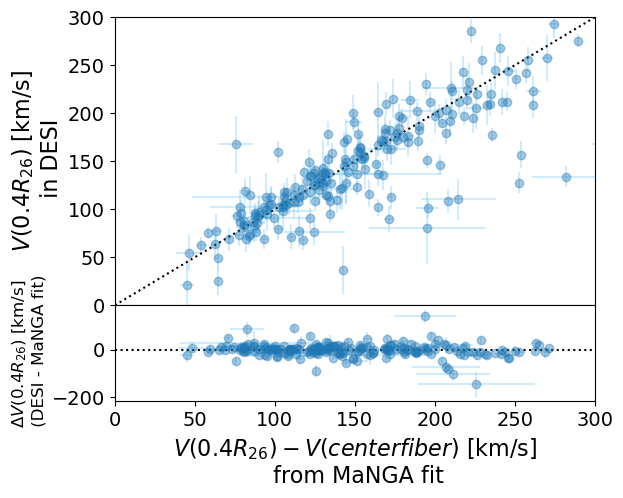

In [215]:
# Remake the same figure as we do in `PV_MaNGA_comp_Y1.ipynb`

fig = plt.figure(tight_layout=True)

frame1 = fig.add_axes((0.2, 0.35, 0.75, 0.6))

# This isn't quite right - the sign needs to change depending on which side of the galaxy the observations are from
plt.errorbar(final_MaNGA_sample['Vfit_corr_0p4R26'] - final_MaNGA_sample['V_center_MaNGA'], 
             final_MaNGA_sample['V_0p4R26'], 
             xerr=final_MaNGA_sample['Vfit_corr_0p4R26_err'], 
             yerr=final_MaNGA_sample['V_0p4R26_ERR'], 
             fmt='o', 
             ecolor='lightskyblue',
            alpha=0.4)
plt.plot([0, 1000], [0, 1000], 'k:')

plt.xlim(0, 300)
plt.ylim(0, 300)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.ylabel('$V(0.4R_{26})$ [km/s]\n in DESI', fontsize=16)

frame1.axes.get_xaxis().set_visible(False)


frame2 = fig.add_axes((0.2, 0.15, 0.75, 0.2))

plt.errorbar(final_MaNGA_sample['Vfit_corr_0p4R26'], final_MaNGA_sample['V_0p4R26'] - final_MaNGA_sample['Vfit_corr_0p4R26'], 
             xerr=final_MaNGA_sample['Vfit_corr_0p4R26_err'], 
             yerr=np.sqrt(final_MaNGA_sample['V_0p4R26_ERR']**2 + final_MaNGA_sample['Vfit_corr_0p4R26_err']**2), 
             fmt='o', 
             ecolor='lightskyblue',
            alpha=0.4)
plt.hlines(0, 0, 350, linestyles='dotted', colors='k')

plt.xlim(0, 300)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel('$V(0.4R_{26}) - V(center fiber)$ [km/s]\n from MaNGA fit', fontsize=16)
plt.ylabel('$\Delta V(0.4R_{26})$ [km/s]\n (DESI - MaNGA fit)');

<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2272339/647945532.py:40: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$\Delta V(0.4R_{26})$ [km/s]\n (DESI - MaNGA fit)');


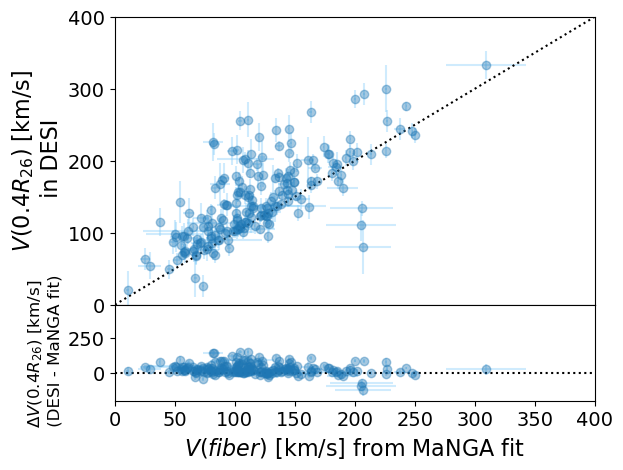

In [212]:
# Remake the same figure as we do in `PV_MaNGA_comp_Y1.ipynb`

fig = plt.figure(tight_layout=True)

frame1 = fig.add_axes((0.2, 0.35, 0.75, 0.6))

plt.errorbar(final_MaNGA_sample['V_0p4R26_MaNGA'], final_MaNGA_sample['V_0p4R26'], 
             xerr=final_MaNGA_sample['V_0p4R26_MaNGA_ERR'], 
             yerr=final_MaNGA_sample['V_0p4R26_ERR'], 
             fmt='o', 
             ecolor='lightskyblue',
            alpha=0.4)
plt.plot([0, 1000], [0, 1000], 'k:')

plt.xlim(0, 400)
plt.ylim(0, 400)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.ylabel('$V(0.4R_{26})$ [km/s]\n in DESI', fontsize=16)

frame1.axes.get_xaxis().set_visible(False)


frame2 = fig.add_axes((0.2, 0.15, 0.75, 0.2))

plt.errorbar(final_MaNGA_sample['V_0p4R26_MaNGA'], final_MaNGA_sample['V_0p4R26'] - final_MaNGA_sample['V_0p4R26_MaNGA'], 
             xerr=final_MaNGA_sample['V_0p4R26_MaNGA_ERR'], 
             yerr=np.sqrt(final_MaNGA_sample['V_0p4R26_ERR']**2 + final_MaNGA_sample['V_0p4R26_MaNGA_ERR']**2), 
             fmt='o', 
             ecolor='lightskyblue',
             alpha=0.4)
plt.hlines(0, 0, 400, linestyles='dotted', colors='k')

plt.xlim(0, 400)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel('$V(fiber)$ [km/s] from MaNGA fit', fontsize=16)
plt.ylabel('$\Delta V(0.4R_{26})$ [km/s]\n (DESI - MaNGA fit)');

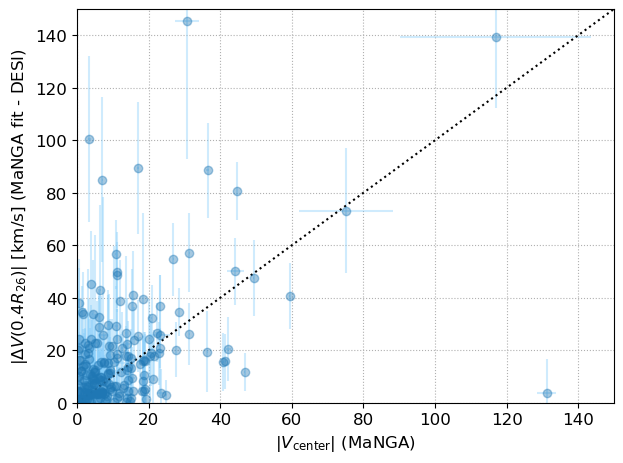

In [221]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(np.abs(final_MaNGA_sample['V_center_MaNGA']), 
             np.abs(final_MaNGA_sample['Vfit_corr_0p4R26'] - final_MaNGA_sample['V_0p4R26']), 
             yerr=np.sqrt(final_MaNGA_sample['V_0p4R26_ERR']**2 + final_MaNGA_sample['Vfit_corr_0p4R26_err']**2), 
             xerr=final_MaNGA_sample['V_center_MaNGA_ERR'],
             fmt='o', 
             ecolor='lightskyblue', 
             alpha=0.4)

plt.plot([0, 150], [0, 150], 'k:')

plt.xlim((0,150))
plt.ylim((0,150))

plt.ylabel(r'|$\Delta V(0.4R_{26})$| [km/s] (MaNGA fit - DESI)')
plt.xlabel(r'|$V_{\rm center}$| (MaNGA)');

        RA                DEC        
------------------ ------------------
 225.7807559589312 31.206000637680663
 225.7807559589312 31.206000637680663
225.78123715633816 31.203921388066558
9045 3702


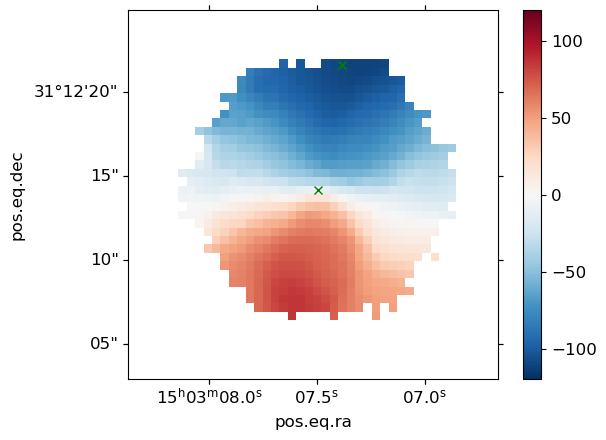

In [203]:
map_idx = 23
sga_gal = 29152

gal_row = SGA_MaNGA['SGA_ID'] == sga_gal
obs_idx = tiron_goodVI['SGA_ID'] == sga_gal
# center_idx = good_centers['SGA_ID'] == sga_gal
print(tiron_goodVI['RA', 'DEC'][obs_idx])

gal_plate = SGA_MaNGA['plate'][gal_row][0]
gal_IFU = SGA_MaNGA['ifudsgn'][gal_row][0]
print(gal_plate, gal_IFU)

file_name = str(gal_plate) + '/' + str(gal_IFU) + '/manga-' + str(gal_plate) + '-' + str(gal_IFU) + '-MAPS-HYB10-MILESHC-MASTARSSP.fits.gz'

hdul = fits.open(VEL_MAP_FOLDER + file_name)
vel = hdul['EMLINE_GVEL']
Ha_vel = vel.data[map_idx]
Ha_ivar = hdul['EMLINE_GVEL_IVAR'].data[map_idx]
Ha_mask = hdul['EMLINE_GVEL_MASK'].data[map_idx]
hdul.close()

mHa_vel = ma.array(Ha_vel, mask=Ha_mask)
mHa_ivar = ma.array(Ha_ivar, mask=Ha_mask)

gal_wcs = WCS(vel.header)

plt.figure()
ax = plt.subplot(projection=gal_wcs, slices=('x', 'y', map_idx))
vel_im = ax.imshow(mHa_vel, cmap='RdBu_r', origin='lower', vmin=-120, vmax=120)
plt.plot(tiron_goodVI['RA'][obs_idx], 
         tiron_goodVI['DEC'][obs_idx], 
         'gx', 
         transform=ax.get_transform('world'))
# plt.plot(good_centers['RA'][center_idx], 
#          good_centers['DEC'][center_idx], 
#          'yx', 
#          transform=ax.get_transform('world'))
plt.colorbar(vel_im, ax=ax);